# 1. Dataset & Pre-processing

## Import libraries

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

## Prepare dataset

### CICIDS217

Gộp các dataset CICIDS lại với nhau

In [ ]:
files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
]

df = pd.concat([pd.read_csv(f"dataset/CICDCS2017/{f}") for f in files], ignore_index=True)
df.columns = df.columns.str.strip()
df.to_csv("dataset/CICIDS2017.csv", index=False)
print(f"✅ CICIDS merged: {df.shape}")

### CAN BUS

Chuẩn hóa cấu trúc các dataset CAN bus 

In [ ]:
import csv

RAW_CAN = 'dataset/CAN-bus'

headers = [
    'Timestamp', 'CAN_ID', 'DLC',
    'Byte1', 'Byte2', 'Byte3', 'Byte4', 'Byte5', 'Byte6', 'Byte7', 'Byte8',
    'Label'
]
byte_cols = [f'Byte{i}' for i in range(1, 9)]

def parse_can_dataset(file_path):
    records = []
    with open(file_path, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 4:
                continue

            row = [x.strip() for x in row]
            timestamp, can_id, dlc_raw = row[:3]
            payload_and_label = row[3:]

            label = payload_and_label[-1] if payload_and_label and payload_and_label[-1] != '' else np.nan
            payload = payload_and_label[:-1]

            dlc_num = pd.to_numeric(dlc_raw, errors='coerce')
            if pd.notna(dlc_num):
                dlc_int = int(max(0, min(8, dlc_num)))
                payload = payload[:dlc_int]
            else:
                dlc_int = np.nan
                payload = payload[:8]

            payload = [b if b != '' else np.nan for b in payload]
            payload += [np.nan] * (8 - len(payload))

            records.append([timestamp, can_id, dlc_int, *payload, label])

    df = pd.DataFrame(records, columns=headers)
    df['DLC'] = pd.to_numeric(df['DLC'], errors='coerce').astype('Int64')
    return df

summary = []
def normalize_and_save(input_path, output_path, keep_df=False):
    df = parse_can_dataset(input_path)
    df.to_csv(output_path, index=False)

    label_counts = df['Label'].value_counts(dropna=False)
    misplaced_rt = int(df[byte_cols].isin(['R', 'T']).sum().sum())
    summary.append({
        'file': input_path.split('/')[-1],
        'rows': len(df),
        'R_in_Label': int(label_counts.get('R', 0)),
        'T_in_Label': int(label_counts.get('T', 0)),
        'RT_in_Byte_cols': misplaced_rt,
        'output': output_path.split('/')[-1]
    })

    if keep_df:
        return df
    return None

df_rpm = normalize_and_save(f'{RAW_CAN}/RPM_dataset.csv',   f'{RAW_CAN}/RPM_dataset_new.csv',   keep_df=True)
normalize_and_save(          f'{RAW_CAN}/Fuzzy_dataset.csv', f'{RAW_CAN}/Fuzzy_dataset_new.csv')
normalize_and_save(          f'{RAW_CAN}/gear_dataset.csv',  f'{RAW_CAN}/gear_dataset_new.csv')
normalize_and_save(          f'{RAW_CAN}/DoS_dataset.csv',   f'{RAW_CAN}/DoS_dataset_new.csv')

summary_df = pd.DataFrame(summary)
summary_df

In [ ]:
df_fuzzy = pd.read_csv(f"{RAW_CAN}/Fuzzy_dataset_new.csv")
df_fuzzy['Label'] = df_fuzzy['Label'].replace({'T': 'Fuzzy'})
for col in byte_cols:
    df_fuzzy[col] = df_fuzzy[col].apply(lambda x: int(x, 16) if pd.notna(x) and isinstance(x, str) else (x if pd.isna(x) else int(x)))
    df_fuzzy[col] = df_fuzzy[col].astype('Int64')
df_fuzzy.to_csv(f"{RAW_CAN}/Fuzzy_dataset_new.csv", index=False)
df_fuzzy['Label'].value_counts(dropna=False)

In [31]:
df_fuzzy

,Timestamp,CAN_ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.478196e+09,0545,8,216,0,0,138,0,0,0,0,R
1,1.478196e+09,02b0,5,255,127,0,5,73,<NA>,<NA>,<NA>,R
2,1.478196e+09,0002,8,0,0,0,0,0,1,7,21,R
3,1.478196e+09,0153,8,0,33,16,255,0,255,0,0,R
4,1.478196e+09,0130,8,25,128,0,255,254,127,7,96,R
...,...,...,...,...,...,...,...,...,...,...,...,...
3838855,1.478201e+09,018f,8,254,89,0,0,0,65,0,0,R
3838856,1.478201e+09,0260,8,24,33,33,48,8,143,109,25,R
3838857,1.478201e+09,02a0,8,36,0,154,29,151,2,189,0,R
3838858,1.478201e+09,0329,8,220,183,127,20,17,32,0,20,R


In [ ]:
df_rpm = pd.read_csv(f"{RAW_CAN}/RPM_dataset_new.csv")
df_rpm['Label'] = df_rpm['Label'].replace({'T': 'RPM'})
for col in byte_cols:
    df_rpm[col] = df_rpm[col].apply(lambda x: int(x, 16) if pd.notna(x) and isinstance(x, str) else (x if pd.isna(x) else int(x)))
    df_rpm[col] = df_rpm[col].astype('Int64')
df_rpm.to_csv(f"{RAW_CAN}/RPM_dataset_new.csv", index=False)
df_rpm['Label'].value_counts(dropna=False)

In [32]:
df_rpm

,Timestamp,CAN_ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.478191e+09,0316,8,5,34,104,9,34,32,0,117,R
1,1.478191e+09,018f,8,254,59,0,0,0,60,0,0,R
2,1.478191e+09,0260,8,25,34,34,48,255,143,110,63,R
3,1.478191e+09,02a0,8,96,0,131,29,150,2,189,0,R
4,1.478191e+09,0329,8,220,184,126,20,17,32,0,20,R
...,...,...,...,...,...,...,...,...,...,...,...,...
4621697,1.478201e+09,018f,8,254,89,0,0,0,65,0,0,R
4621698,1.478201e+09,0260,8,24,33,33,48,8,143,109,25,R
4621699,1.478201e+09,02a0,8,36,0,154,29,151,2,189,0,R
4621700,1.478201e+09,0329,8,220,183,127,20,17,32,0,20,R


In [ ]:
df_gear = pd.read_csv(f"{RAW_CAN}/gear_dataset_new.csv")
df_gear['Label'] = df_gear['Label'].replace({'T': 'Gear'})
for col in byte_cols:
    df_gear[col] = df_gear[col].apply(lambda x: int(x, 16) if pd.notna(x) and isinstance(x, str) else (x if pd.isna(x) else int(x)))
    df_gear[col] = df_gear[col].astype('Int64')
df_gear.to_csv(f"{RAW_CAN}/gear_dataset_new.csv", index=False)
df_gear['Label'].value_counts(dropna=False)

In [33]:
df_gear

,Timestamp,CAN_ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.478193e+09,0140,8,0,0,0,0,16,41,42,36,R
1,1.478193e+09,02c0,8,21,0,0,0,0,0,0,0,R
2,1.478193e+09,0350,8,5,32,68,104,119,0,0,126,R
3,1.478193e+09,0370,8,0,32,0,0,0,0,0,0,R
4,1.478193e+09,043f,8,16,64,96,255,120,196,8,0,R
...,...,...,...,...,...,...,...,...,...,...,...,...
4443137,1.478201e+09,018f,8,254,89,0,0,0,65,0,0,R
4443138,1.478201e+09,0260,8,24,33,33,48,8,143,109,25,R
4443139,1.478201e+09,02a0,8,36,0,154,29,151,2,189,0,R
4443140,1.478201e+09,0329,8,220,183,127,20,17,32,0,20,R


In [ ]:
df_dos = pd.read_csv(f"{RAW_CAN}/DoS_dataset_new.csv")
df_dos['Label'] = df_dos['Label'].replace({'T': 'DoS'})
for col in byte_cols:
    df_dos[col] = df_dos[col].apply(lambda x: int(x, 16) if pd.notna(x) and isinstance(x, str) else (x if pd.isna(x) else int(x)))
    df_dos[col] = df_dos[col].astype('Int64')
df_dos.to_csv(f"{RAW_CAN}/DoS_dataset_new.csv", index=False)
df_dos['Label'].value_counts(dropna=False)

In [34]:
df_dos

,Timestamp,CAN_ID,DLC,Byte1,Byte2,Byte3,Byte4,Byte5,Byte6,Byte7,Byte8,Label
0,1.478198e+09,0316,8,5,33,104,9,33,33,0,111,R
1,1.478198e+09,018f,8,254,91,0,0,0,60,0,0,R
2,1.478198e+09,0260,8,25,33,34,48,8,142,109,58,R
3,1.478198e+09,02a0,8,100,0,154,29,151,2,189,0,R
4,1.478198e+09,0329,8,64,187,127,20,17,32,0,20,R
...,...,...,...,...,...,...,...,...,...,...,...,...
3665766,1.478201e+09,018f,8,254,89,0,0,0,65,0,0,R
3665767,1.478201e+09,0260,8,24,33,33,48,8,143,109,25,R
3665768,1.478201e+09,02a0,8,36,0,154,29,151,2,189,0,R
3665769,1.478201e+09,0329,8,220,183,127,20,17,32,0,20,R


In [ ]:
can_files = [
    f"{RAW_CAN}/DoS_dataset_new.csv",
    f"{RAW_CAN}/gear_dataset_new.csv",
    f"{RAW_CAN}/Fuzzy_dataset_new.csv",
    f"{RAW_CAN}/RPM_dataset_new.csv",
]

df = pd.concat([pd.read_csv(f) for f in can_files], ignore_index=True)
df.to_csv("dataset/CAN_BUS.csv", index=False)
print(f"✅ CAN merged: {df.shape}")

### Preprocessing (normalization and padding values)

In [ ]:
df_cicids = pd.read_csv("dataset/CICIDS2017.csv")

In [ ]:
df_can = pd.read_csv("dataset/CAN_BUS.csv")

In [49]:
df_can['CAN_ID'] = df_can['CAN_ID'].apply(lambda x: int(x, 16) if pd.notna(x) and isinstance(x, str) else (x if pd.isna(x) else int(x)))

In [ ]:
df_cicids = df_cicids.replace([np.inf, -np.inf], np.nan)
# Fill empty values by 0
df_cicids = df_cicids.fillna(0)

In [ ]:
df_can = df_can.replace([np.inf, -np.inf], np.nan)
# Fill empty values by 0
df_can = df_can.fillna(0)

### Split → Normalize → SMOTE → Save

In [ ]:
# ─── CICIDS Pipeline ─────────────────────────────────────────────────────────
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

OUT_CICIDS = Path('dataset/Data_Preprocessing/CICIDS')
OUT_CICIDS.mkdir(parents=True, exist_ok=True)

# Label encode
le_cicids = LabelEncoder()
df_cicids['Label'] = le_cicids.fit_transform(df_cicids['Label'])

# Preserve feature column names before converting to numpy
feature_cols_cicids = [c for c in df_cicids.columns if c != 'Label']
X = df_cicids[feature_cols_cicids].values
y = df_cicids['Label'].values.astype(np.int64)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0, stratify=y
)

# Min-Max normalize (fit on train only, transform both)
scaler_cicids = MinMaxScaler()
X_train = scaler_cicids.fit_transform(X_train)
X_test  = scaler_cicids.transform(X_test)

# SMOTE for all extreme minority classes
smote_cicids = SMOTE(
    sampling_strategy={8: 1200, 9: 1200, 13: 1200, 14: 1200},
    random_state=0
)
X_train, y_train = smote_cicids.fit_resample(X_train, y_train)

# Save with column names as parquet
pd.DataFrame(X_train, columns=feature_cols_cicids).to_parquet(OUT_CICIDS / 'X_train_CICIDS_smote.parquet', index=False)
pd.DataFrame(X_test,  columns=feature_cols_cicids).to_parquet(OUT_CICIDS / 'X_test_CICIDS.parquet',       index=False)
pd.Series(y_train, name='Label').to_frame().to_parquet(OUT_CICIDS / 'y_train_CICIDS.parquet', index=False)
pd.Series(y_test,  name='Label').to_frame().to_parquet(OUT_CICIDS / 'y_test_CICIDS.parquet',  index=False)

print(f"✅ CICIDS saved → {OUT_CICIDS}")
print(f"   X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"   y_train class counts: {dict(sorted(pd.Series(y_train).value_counts().items()))}")
print(f"   Features ({len(feature_cols_cicids)}): {feature_cols_cicids[:5]} ...")

In [ ]:
# ─── CAN Pipeline ────────────────────────────────────────────────────────────
OUT_CAN = Path('dataset/Data_Preprocessing/CAN bus')
OUT_CAN.mkdir(parents=True, exist_ok=True)

# TimeDelta: compute on FULL dataset BEFORE split (grouped by CAN_ID, sorted by Timestamp)
df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce').fillna(0.0)
df_can['CAN_ID']    = pd.to_numeric(df_can['CAN_ID'],    errors='coerce').fillna(0.0)
df_can = df_can.sort_values(['CAN_ID', 'Timestamp']).reset_index(drop=True)
df_can['TimeDelta'] = df_can.groupby('CAN_ID')['Timestamp'].diff().fillna(0.0)

# Label encode
le_can = LabelEncoder()
df_can['Label'] = le_can.fit_transform(df_can['Label'])

# Preserve feature column names
feature_cols_can = [c for c in df_can.columns if c != 'Label']
X = df_can[feature_cols_can].values
y = df_can['Label'].values.astype(np.int64)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0, stratify=y
)

# Min-Max normalize (fit on train only, transform both)
scaler_can = MinMaxScaler()
X_train = scaler_can.fit_transform(X_train)
X_test  = scaler_can.transform(X_test)

# Save with column names as parquet
pd.DataFrame(X_train, columns=feature_cols_can).to_parquet(OUT_CAN / 'X_train_CAN_smote.parquet', index=False)
pd.DataFrame(X_test,  columns=feature_cols_can).to_parquet(OUT_CAN / 'X_test_CAN.parquet',       index=False)
pd.Series(y_train, name='Label').to_frame().to_parquet(OUT_CAN / 'y_train_CAN.parquet', index=False)
pd.Series(y_test,  name='Label').to_frame().to_parquet(OUT_CAN / 'y_test_CAN.parquet',  index=False)

print(f"✅ CAN saved → {OUT_CAN}")
print(f"   X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"   y_train class counts: {dict(sorted(pd.Series(y_train).value_counts().items()))}")
print(f"   Features ({len(feature_cols_can)}): {feature_cols_can}")

# Machine learning model training

## Training four base learners: decision tree, random forest, extra trees, XGBoost

Accuracy of DT: 0.9999951718446118
Precision of DT: 0.99999517187174
Recall of DT: 0.9999951718446118
F1-score of DT: 0.9999951716550497
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117504
           1       1.00      1.00      1.00     98369
           2       1.00      1.00      1.00    119451
           3       1.00      1.00      1.00   2847592
           4       1.00      1.00      1.00    130979

    accuracy                           1.00   3313895
   macro avg       1.00      1.00      1.00   3313895
weighted avg       1.00      1.00      1.00   3313895



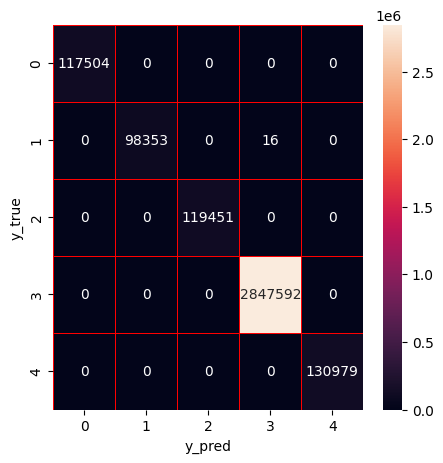

In [57]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()